# Clinical Risk Prediction Using Explainable Machine Learning

This project develops machine learning workflows for predicting hospital readmission risk using healthcare data from U.S. hospitals. The analysis compares statistical and ensemble learning approaches, evaluates predictive performance, and investigates clinically important predictors associated with patient readmission.

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [6]:
# Load dataset

df = pd.read_csv(
    r"C:\Users\chatt\OneDrive\Documents\GitHub Files\clinical_risk_prediction\data\diabetic_data.csv"
)

# View dimensions
print(df.shape)

# Preview first rows
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
# Check missing values

missing_values = (df == "?").sum()

# Show columns with missing values
missing_values[missing_values > 0].sort_values(ascending=False)

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [8]:
# Remove columns with too many missing values

df = df.drop(
    columns=[
        "weight",
        "payer_code",
        "medical_specialty"
    ]
)

# Replace ? with NaN
df = df.replace("?", np.nan)

# Remove remaining missing rows
df = df.dropna()

# Check new dimensions
print(df.shape)

(289, 47)


In [9]:
# Reload original dataset

df = pd.read_csv(
    r"C:\Users\chatt\OneDrive\Documents\GitHub Files\clinical_risk_prediction\data\diabetic_data.csv"
)

print(df.shape)

(101766, 50)


In [10]:
# Replace ? with NaN

df = df.replace("?", np.nan)

# Drop columns with excessive missing values

df = df.drop(
    columns=[
        "weight",
        "payer_code",
        "medical_specialty"
    ]
)

# Check remaining missing values

missing_after = df.isnull().sum()

missing_after[missing_after > 0].sort_values(ascending=False)

max_glu_serum    96420
A1Cresult        84748
race              2273
diag_3            1423
diag_2             358
diag_1              21
dtype: int64

In [11]:
# Drop columns with excessive missingness

df = df.drop(
    columns=[
        "max_glu_serum",
        "A1Cresult"
    ]
)

# Remove remaining rows with missing values

df = df.dropna()

# Final dataset dimensions

print(df.shape)

(98053, 45)


In [12]:
# Examine target variable

df["readmitted"].value_counts()

readmitted
NO     52338
>30    34649
<30    11066
Name: count, dtype: int64

In [13]:
# Convert target into binary classification

df["readmitted_binary"] = df["readmitted"].apply(
    lambda x: 0 if x == "NO" else 1
)

# Check distribution

df["readmitted_binary"].value_counts()

readmitted_binary
0    52338
1    45715
Name: count, dtype: int64

In [14]:
# Remove identifier columns

df = df.drop(
    columns=[
        "encounter_id",
        "patient_nbr",
        "readmitted"
    ]
)

print(df.shape)

(98053, 43)


In [15]:
# Identify categorical columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print(categorical_columns)

Index(['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed'],
      dtype='object')


In [16]:
# Encode categorical variables

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

# Check transformed dataset
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary
1,2,0,1,1,1,7,3,59,0,18,...,0,3,1,0,0,0,0,0,1,1
2,0,0,2,1,1,7,2,11,5,13,...,0,1,1,0,0,0,0,1,1,0
3,2,1,3,1,1,7,2,44,1,16,...,0,3,1,0,0,0,0,0,1,0
4,2,1,4,1,1,7,1,51,0,8,...,0,2,1,0,0,0,0,0,1,0
5,2,1,5,2,1,2,3,31,6,16,...,0,2,1,0,0,0,0,1,1,1


In [17]:
# Separate features and target

X = df.drop(columns=["readmitted_binary"])

y = df["readmitted_binary"]

print(X.shape)
print(y.shape)

(98053, 42)
(98053,)


In [18]:
# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(78442, 42)
(19611, 42)


In [20]:
# Logistic Regression model

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:")
print(log_accuracy)

Logistic Regression Accuracy:
0.6139411554739687


C:\Users\chatt\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
# Random Forest model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:")
print(rf_accuracy)

Random Forest Accuracy:
0.629901585844679


In [22]:
# Classification report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.63      0.72      0.67     10432
           1       0.62      0.53      0.57      9179

    accuracy                           0.63     19611
   macro avg       0.63      0.62      0.62     19611
weighted avg       0.63      0.63      0.63     19611



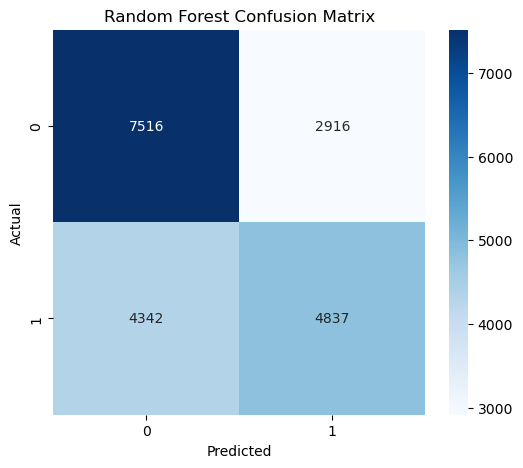

In [23]:
# Confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

ROC-AUC Score:
0.6801885791671038


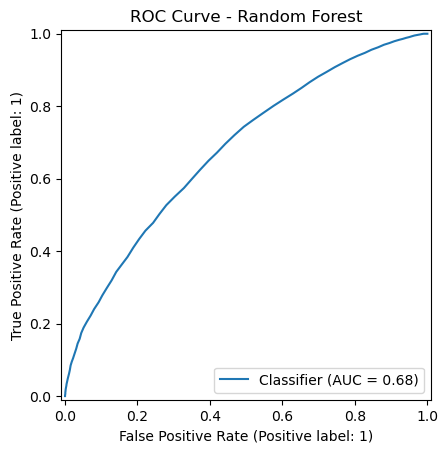

In [24]:
# ROC-AUC evaluation

from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Predicted probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ROC-AUC score
roc_score = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC Score:")
print(roc_score)

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("ROC Curve - Random Forest")
plt.show()

                     Feature  Importance
7         num_lab_procedures    0.099532
13                    diag_1    0.095209
14                    diag_2    0.093427
15                    diag_3    0.091272
9            num_medications    0.086030
6           time_in_hospital    0.061057
12          number_inpatient    0.051442
2                        age    0.050921
4   discharge_disposition_id    0.045911
16          number_diagnoses    0.041221


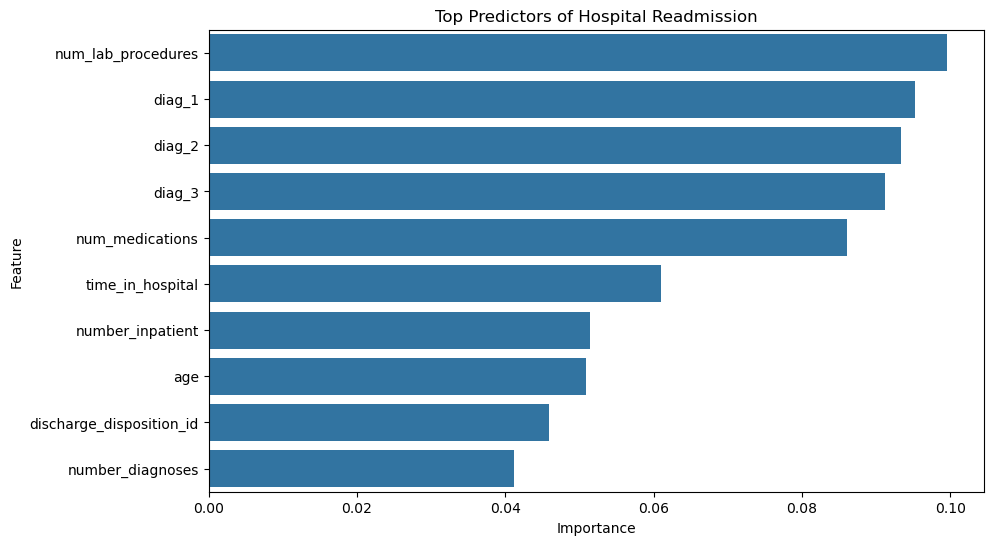

In [25]:
# Feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Top 10 features
top_features = feature_importance.head(10)

print(top_features)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Predictors of Hospital Readmission")

plt.show()

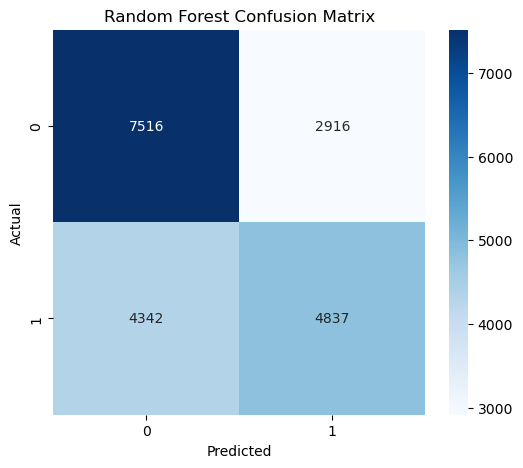

In [29]:
# Save confusion matrix figure

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.savefig(
    r"C:\Users\chatt\OneDrive\Documents\GitHub Files\clinical_risk_prediction\figures\confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

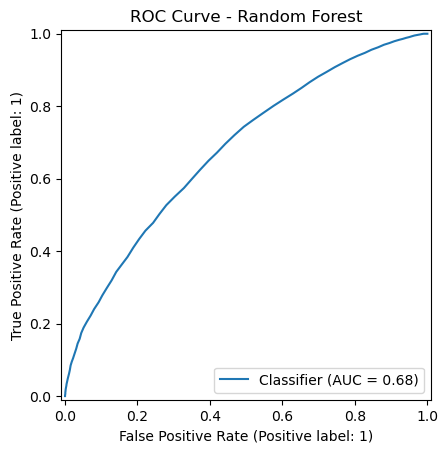

In [30]:
# Save ROC curve

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("ROC Curve - Random Forest")

plt.savefig(
    r"C:\Users\chatt\OneDrive\Documents\GitHub Files\clinical_risk_prediction\figures\roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

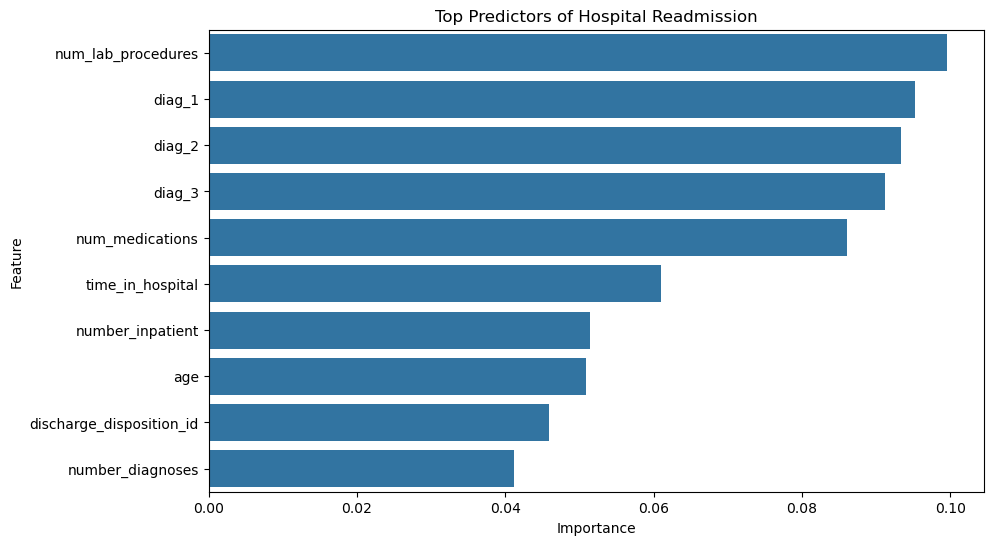

In [31]:
# Save feature importance plot

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Predictors of Hospital Readmission")

plt.savefig(
    r"C:\Users\chatt\OneDrive\Documents\GitHub Files\clinical_risk_prediction\figures\feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()